In [1]:
# Stage 1: Import Libraries
# Importing the libraries required for data analysis, visualization, model training, and evaluation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
# Stage 2: Load Dataset
# Loading the dataset into a DataFrame.

In [4]:
df = pd.read_csv("data.csv")

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [5]:
# Stage 3: Data Understanding
# Checking dataset size, columns, data types, and missing values.

In [6]:
df.shape

(4600, 18)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [8]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [9]:
# Stage 4: Data Cleaning
# Removing columns that won't help in predicting house prices.

In [10]:
df = df.drop(['street', 'country'], axis=1)

In [11]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

df.drop('date', axis=1, inplace=True)

In [12]:
# Remove houses with price = 0
df = df[df['price'] > 0]

In [13]:
# Remove extreme price outliers
# Extreme house prices can distort machine learning models and reduce prediction accuracy. Removing them helps the model learn more meaningful patterns from the data.

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df['price'] >= lower) &
    (df['price'] <= upper)
]

In [14]:
# Stage 5: Exploratory Data Analysis
# Understanding house prices and important features.

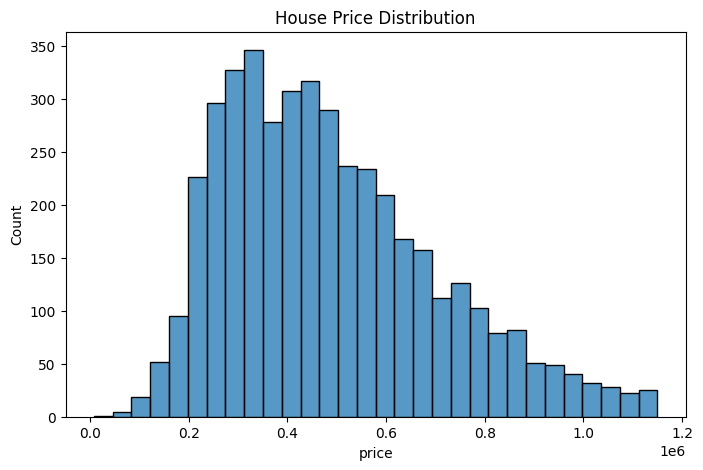

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30)
plt.title("House Price Distribution")
plt.show()

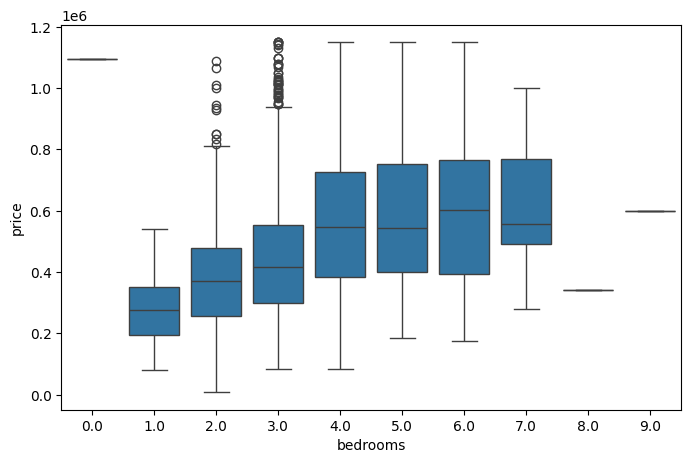

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='bedrooms', y='price', data=df)
plt.show()

In [17]:
df.groupby('city')['price'].mean().sort_values(ascending=False).head(10)

city
Clyde Hill            994000.000000
Mercer Island         811107.186667
Beaux Arts Village    745000.000000
Bellevue              681543.557830
Sammamish             674910.103121
Redmond               640074.857593
Newcastle             631598.096774
Woodinville           593763.761261
Kirkland              585231.145948
Issaquah              577834.605343
Name: price, dtype: float64

In [18]:
# Stage 6: Feature Encoding
# Converting text columns into numbers.

In [19]:
df = pd.get_dummies(
    df,
    columns=['city', 'statezip'],
    drop_first=True
)

In [20]:
# Stage 7: Feature Selection
# Separating features and target variable.

In [21]:
X = df.drop('price', axis=1)

y = df['price']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
# Stage 9: Linear Regression
# Training Linear Regression model.

In [24]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

r2_lr = r2_score(y_test, pred_lr)

print("R2 Score:", r2_lr)

R2 Score: 0.7800891347879122


In [25]:
# Stage 10: Decision Tree Regressor

In [26]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

r2_dt = r2_score(y_test, pred_dt)

print("R2 Score:", r2_dt)

R2 Score: 0.5145359633059625


In [27]:
# Stage 11: Random Forest Regressor

In [28]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, pred_rf)

print("R2 Score:", r2_rf)

R2 Score: 0.7297508748235326


In [29]:
# Stage 12: Gradient Boosting Regressor

In [30]:
gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

r2_gb = r2_score(y_test, pred_gb)

print("R2 Score:", r2_gb)

R2 Score: 0.7221788433675519


In [31]:
# Stage 13: Model Comparison
# Comparing all models.

In [32]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'R2 Score': [
        r2_lr,
        r2_dt,
        r2_rf,
        r2_gb
    ]
})

results

,Model,R2 Score
0,Linear Regression,0.780089
1,Decision Tree,0.514536
2,Random Forest,0.729751
3,Gradient Boosting,0.722179


In [33]:
# Stage 14: Best Model Evaluation

In [34]:
print("MAE:",
      mean_absolute_error(
          y_test,
          pred_rf
      ))

print("RMSE:",
      np.sqrt(
          mean_squared_error(
              y_test,
              pred_rf
          )
      ))

MAE: 77486.81805329933
RMSE: 112555.28980896076


In [35]:
# Findings
# 1.The dataset contained 4,600 housing records with features such as bedrooms, bathrooms, living area, location, and construction year.
# 2. During data preprocessing, houses with a price of 0 and extreme price outliers were removed to improve model performance and reduce data distortion.
# 3. Linear Regression achieved the highest R² score of 0.7801, making it the best-performing model in this analysis.
# 4. Random Forest and Gradient Boosting also performed well, achieving R² scores of 0.7298 and 0.7222 respectively.
# 5. Decision Tree Regressor achieved an R² score of 0.5145, which was lower than the other models.
# 6. The best model achieved a Mean Absolute Error (MAE) of approximately 77,487, indicating the average prediction error in house prices.
# 7. The Root Mean Squared Error (RMSE) was approximately 112,555, showing that the model was able to predict house prices with reasonable accuracy.